# Klassificering av ansiktsuttryck med CNN

In [1]:
# Importerar bibliotek för hela min kod 
import time, os 
import numpy as np,pandas as pd, matplotlib.pyplot as plt 


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers, models

from tensorflow.keras.utils import load_img, img_to_array

# slump seed  
tf.keras.utils.set_random_seed(42)

# Laddar dataset 

- jag använder  image_dataset_from_directory för att läsa in bilderna i gråskala och ändrar storleken till 48x48 pixlar. 
- jag upp träningsmappen med validation_split: 80% av bilderna tränar modellen på, och 20% sparas som validering för att testa modellen under träningens gång.

In [2]:
# Laddar in data från mappar i datan 
train_path = "FER-2013/train"
test_path = "FER-2013/test"
 

img_size = (48, 48)  # Ändrar alla bilder till storlek 48 * 48 
batch_size = 32   # hur många bilder modellen läser in samtidigt 

# Lägger till validation_split för att övervaka overfittning 
train_data =tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset= "training",
    seed = 42,
    color_mode ="grayscale",
    image_size =img_size,
    batch_size = batch_size,
    label_mode = "int" 
)


val_data =tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split= 0.2,
    subset= "validation",
    seed =42,
    color_mode="grayscale",
    image_size =img_size,
    batch_size =batch_size,
    label_mode="int"
)



test_data =tf.keras.utils.image_dataset_from_directory(
    test_path,
    color_mode ="grayscale",
    image_size =img_size,
    batch_size= batch_size
)

# hämtar klassernas name 
class_names =train_data.class_names

# skriver ut klasserna 
print(class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# Undersöka datan

Kollar hur många bilder per klass — disgust har klart minst.

In [3]:
print("klasser:")
print(class_names)


# Räknar antal bild i varje klass 

for category in class_names:
    path =os.path.join(train_path, category)   
    num_images =len(os.listdir(path))     

    print(f"{category}:{num_images} bilder ")


    

klasser:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
angry:3995 bilder 
disgust:436 bilder 
fear:4097 bilder 
happy:7215 bilder 
neutral:4965 bilder 
sad:4830 bilder 
surprise:3171 bilder 


# Exemple bilder 

Visar några exempelbilder så jag ser hur datan ser ut.

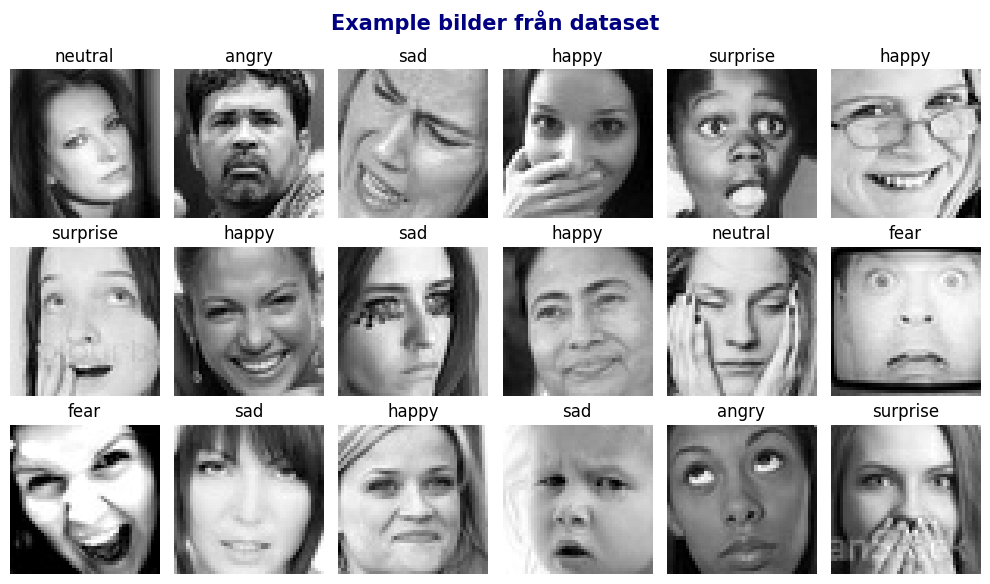

In [4]:
plt.figure(figsize=(10, 6))
plt.suptitle("Example bilder från dataset", fontsize=15,fontweight="bold", color="navy")
for images,labells in train_data.take(1):
    for i in range(18):
        plt.subplot(3, 6, i + 1)

        plt.imshow(images[i].numpy().squeeze(), cmap= "gray")
        plt.title(class_names[labells[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# disgust hade väldigt få bilder så jag lade till augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),     
    layers.RandomRotation(0.1),           
    layers.RandomZoom(0.1),                 #testade 0.2 men blev konstig
])

# Mina  CNN -modeler

In [6]:
# Enkel modell utan dropout
enkla_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48, 48, 1)), #inbyggd normalisering

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2 ,2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64,  activation="relu"),
    layers.Dense(len(class_names),  activation ="softmax")
])

enkla_model.compile(
    optimizer="Adam",
    loss ="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

d:\Data scientist\Deep learning\Individual uppgift\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
#  Bättre modell med dropout och augmentation  

bättre_model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(48, 48, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(256, activation= "relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax")
])


bättre_model.compile(
    optimizer="adam",
    loss= "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



bättre_model.build(input_shape=(None, 48, 48, 1))
bättre_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,458,055 (36.08 MB)

 Trainable params: 9,458,055 (36.08 MB)

 Non-trainable params: 0 (0.00 B)

# Tränar modellen 


In [8]:
# Early stopping ,  den slutar träna om det inte förbättras
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

EPOCHS = 35

print("Tränar enkla modellen")
start_b = time.time()
träning_enkel = enkla_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)
print(f"Träningstid enkla_model: {time.time() - start_b:.2f} sekunder\n")

print("tränar bättre_model")
start_i = time.time()
träning_bättre = bättre_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)
print(f"Träningstid bättre model : {time.time() - start_i:.2f} sekunder")

Tränar enkla modellen
Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.3598 - loss: 1.6414 - val_accuracy: 0.4344 - val_loss: 1.4917
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.4636 - loss: 1.4178 - val_accuracy: 0.4698 - val_loss: 1.3846
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5022 - loss: 1.3141 - val_accuracy: 0.4849 - val_loss: 1.3424
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.5367 - loss: 1.2282 - val_accuracy: 0.4917 - val_loss: 1.3253
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.5704 - loss: 1.1457 - val_accuracy: 0.5029 - val_loss: 1.3037
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6020 - loss: 1.0656 - val_accuracy: 0.4963 - val_loss: 1.3261
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.6325 - loss: 0.9885 - val_accuracy: 0.4966 - val_loss: 1.3616
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.

#  Visar accuracy och loss grafer 

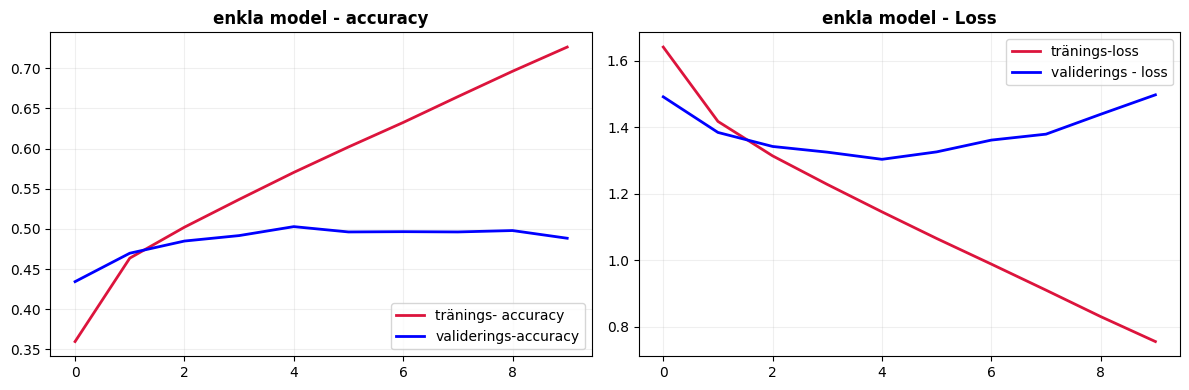

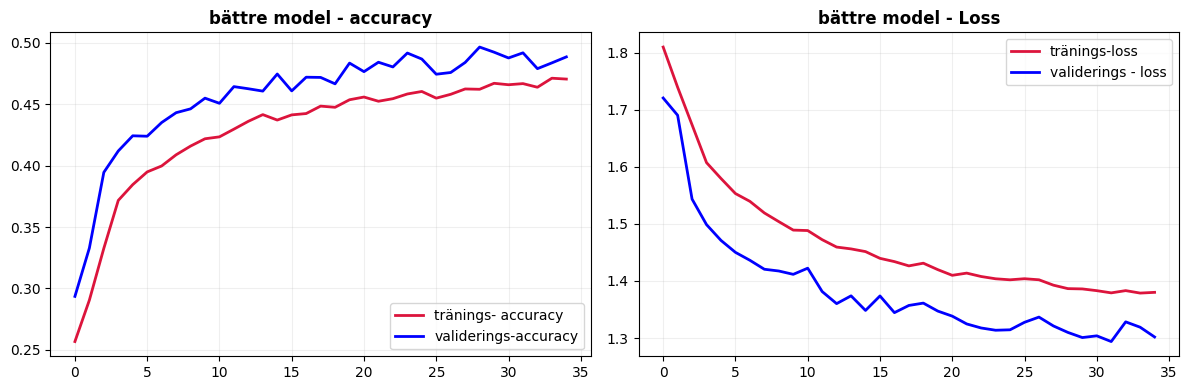

In [9]:
def visa_kurvor(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label= "tränings- accuracy", color="crimson", linewidth=2)
    plt.plot(epochs_range, val_acc, label ="validerings-accuracy", color="blue", linewidth=2)
    plt.legend(loc="lower right")
    plt.title(f"{title} - accuracy", fontweight="bold", fontsize=12)
    plt.grid(True, alpha=0.2)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label= "tränings-loss", color="crimson", linewidth=2)
    plt.plot(epochs_range, val_loss, label="validerings - loss", color="blue", linewidth= 2)
    plt.legend(loc="upper right")
    plt.title(f"{title} - Loss", fontweight="bold", fontsize=12)
    plt.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# jämför kurvorna
visa_kurvor(träning_enkel, "enkla model")
visa_kurvor(träning_bättre, "bättre model")

# Testar på osedd data



In [13]:
print("Testar på osedd data:")
test_loss_b, test_acc_b = enkla_model.evaluate(test_data, verbose=0)
print(f"enkla model: {test_acc_b*100:.2f}%")

test_loss_i, test_acc_i = bättre_model.evaluate(test_data, verbose=0)
print(f"bättre model: {test_acc_i*100:.2f}%")



Testar på osedd data:
enkla model: 49.40%
bättre model: 49.94%


# Prediktioner

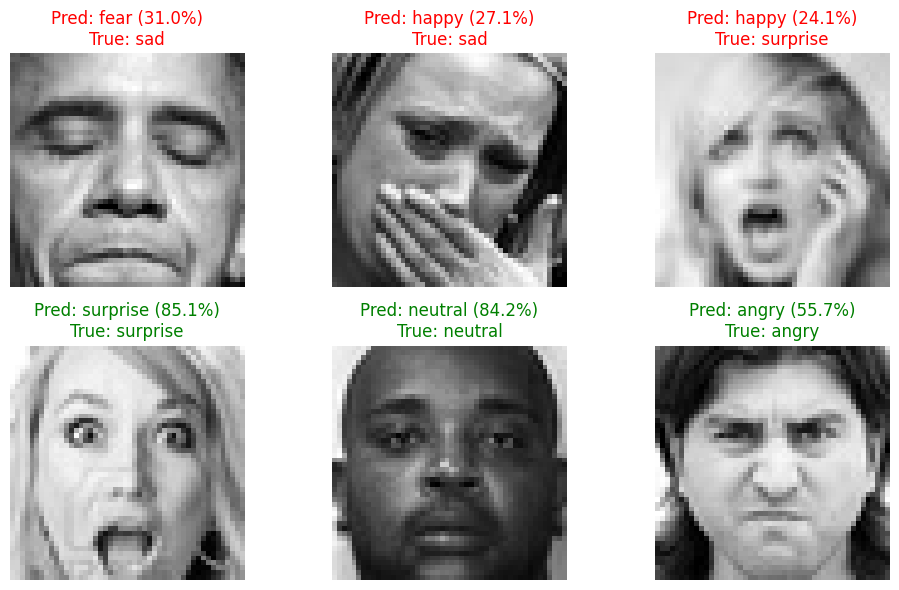

In [14]:
# här plockar ut en batch från test_data (bilder modellen aldrig har sett)
for test_images, test_labels in test_data.take(1):
    predictions = bättre_model.predict(test_images, verbose=0)
    
    plt.figure(figsize=(10, 6))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(test_images[i].numpy().squeeze(), cmap="gray")
        
        pred_label = np.argmax(predictions[i])
        true_label = test_labels[i].numpy()
        confidence = predictions[i][pred_label] * 100
        
        # Grön text om det är rätt, röd om det är fel
        title_color = "green" if pred_label == true_label else 'red'
        
        plt.title(f"Pred: {class_names[pred_label]} ({confidence:.1f}%)\nTrue: {class_names[true_label]}", color=title_color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Analysera modellen 

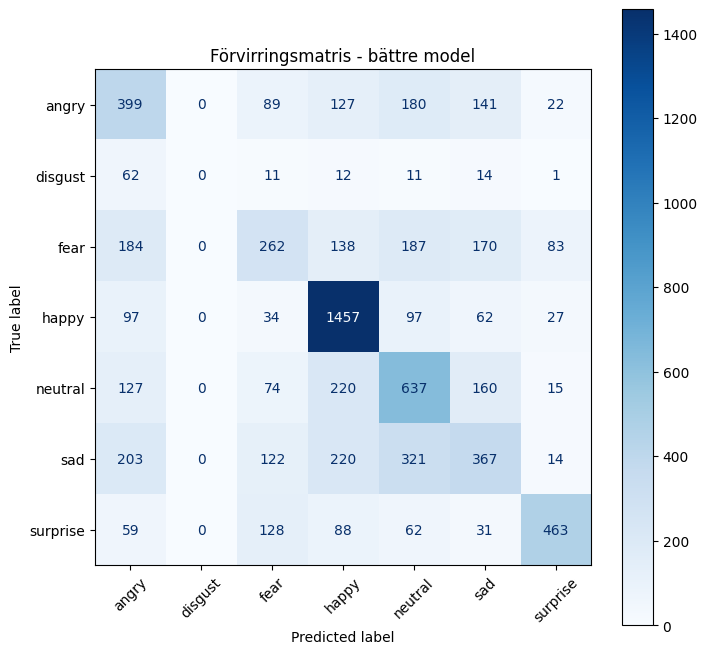


Klassificerings rapport
              precision    recall  f1-score   support

       angry       0.35      0.42      0.38       958
     disgust       0.00      0.00      0.00       111
        fear       0.36      0.26      0.30      1024
       happy       0.64      0.82      0.72      1774
     neutral       0.43      0.52      0.47      1233
         sad       0.39      0.29      0.33      1247
    surprise       0.74      0.56      0.64       831

    accuracy                           0.50      7178
   macro avg       0.42      0.41      0.41      7178
weighted avg       0.48      0.50      0.48      7178



d:\Data scientist\Deep learning\Individual uppgift\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Data scientist\Deep learning\Individual uppgift\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Data scientist\Deep learning\Individual uppgift\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [12]:
# samlar prediktioner för hela testdatan
y_true = []
y_pred = []

for images, labels in test_data:
    preds = bättre_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Detaljerad rapport med precision, recall och f1 score per klass.
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Förvirringsmatris - bättre model")
plt.show()


print("\nKlassificerings rapport")
print(classification_report(y_true, y_pred, target_names=class_names))

## Vad jag testade för att förbättra modellen

Jag provade flera saker under arbetets gång:

- Körde först den bättre modellen men den fick väldigt låg accuracy i början.
- Lade till ett extra Conv2D-lager (128 filter) men det hjälpte inte nämnvärt.
- Tog bort augmentation och testade — det gick snabbare men överanpassade direkt.
- Testade att köra med 35 max-epochs med Early Stopping och landade till slut på **49.94%** på osedd testdata, vilket precis slår basmodellen som fick **49.40%**.

Augmentation gör träningen svårare för modellen, vilket kräver mer tid, men det hjälper till att trycka ner den kraftiga overfittingen som basmodellen led av.

## När är deep learning ett bra val?

Deep learning passar bra för det här problemet eftersom vi jobbar med bilder 
och CNN-modeller är designade för att hitta mönster i pixeldata automatiskt. 
Det hade varit svårt att skriva regler för hand som säger vad som skiljer 
"happy" från "sad" i ett ansikte.

Men deep learning är inte alltid rätt val. Det krävs mycket data — och i det 
här datasetet ser jag  tydligt att klasser med få bilder (t.ex. disgust) är svåra 
för modellen att lära sig. En enklare modell som logistisk regression hade 
förmodligen fungerat dåligt här eftersom bilddata är komplex och högdimensionell.

Deep learning passar när:
- datan är bilder, ljud eller text
- det finns tillräckligt med träningsdata
- mönstren är för komplexa för handskrivna regler

Deep learning passar sämre när:
- datasetet är litet
- man behöver kunna förklara exakt varför modellen fattar ett beslut
- en enklare modell ger liknande resultat med mindre beräkningskraft

# Analysera modellen och diskutera overfitting/underfitting

**Hur bra fungerar modellen?** Min bättre modell fick **49.94%** och den enkla modellen fick **49.40%** på helt osedd testdata. Skillnaden i ren accuracy är väldigt liten, men den bättre modellen hanterar overfitting betydligt bättre, vilket syns tydligt i graferna.

**Tecken på overfitting:** I den enkla modellen ser jag en extremt tydlig overfitting; efter epok 4 fortsätter tränings-loss att sjunka dramatiskt, medan validerings-loss vänder uppåt och sticker iväg. I min bättre modellen har överanpassningen minskat kraftigt med hjälp av Dropout och Early Stopping, och kurvorna följer varandra mycket bättre i en stabil nedåtgående trend.

**Vad påverkar resultatet mest?** Klassbalansen påverkar extremt mycket. Klasser med väldigt få bilder, som **disgust** (endast 436 bilder i träning), har modellen jättesvårt att lära sig. Detta syns svart på vitt i min Confusion Matrix och Classification Report där disgust fick **0.00** i f1-score och 0 korrekta gissningar – modellen gissar istället oftast på *angry* (62 gånger). Matrisen visar också att modellen har svårt för subtila nyanser och ofta blandar ihop känslor, som att **sad** felaktigt klassificeras som **neutral** (321 gånger) eller **angry** (203 gånger).

**Modellens begränsningar:** Bilderna är lågupplösta (48x48) och i gråskala, vilket gör att viktiga detaljer i ansiktsuttryck går förlorade. Modellen är också extremt känslig för den obalanserade datamängden.

# Reflektion och slutsats

**Vad var svårast i uppgiften?** Att förstå varför den bättre modellen inte fick mycket högre accuracy, samt varför den tog så lång tid att träna (över 100 sekunder per epok). När jag granskade min `model.summary()` insåg jag att nätverket hade över 9 miljoner träningsbara parametrar. Det berodde på att jag hade placerat två Conv2D-lager på rad utan ett MaxPooling2D-lager emellan, vilket gjorde att dimensionerna inte skalades ner tillräckligt innan Flatten-lagret.

**Vad lärde du dig?** Att enbart titta på den totala accuracy-siffran kan vara missvisande. Klassificeringsrapporten gav en `UndefinedMetricWarning` för klassen **disgust** eftersom modellen aldrig lyckades förutsäga den på testdatat. Jag lärde mig hur kraftfullt det är att analysera en Confusion Matrix för att förstå exakt vilka mönster och klasser som nätverket missar.

**Vad hade du gjort annorlunda om du började om?** Jag hade lagt till ett MaxPooling2D-lager efter varje enskilt Conv2D-lager i min bättre modell för att få ner parametermängden från 9 miljoner till ett par hundra tusen. Det hade gjort träningen mycket snabbare. Med den sparade tiden hade jag velat experimentera med ännu tyngre Data Augmentation och en lägre learning rate för att försöka lyfta resultatet ytterligare.

**Vilket betyg tycker du att din inlämning motsvarar?** VG.

**Motivering:** Jag har uppfyllt alla grundläggande G-krav genom att bygga en fungerande CNN-modell, utvärdera den korrekt och göra visuella prediktioner. Jag har dessutom uppfyllt VG-kraven genom att utveckla och systematiskt jämföra två olika modellvarianter (en basmodell mot en förbättrad modell med dropout), tolkat träningskurvorna kritiskt utifrån overfitting, samt utfört en djupgående felanalys med förvirringsmatris och klassificeringsrapport där datamängdens begränsningar och obalanser (särskilt fallet med disgust) diskuteras i detalj.